# Personal Safety AI
**Project 07 — Applied AI Engineering**

This notebook builds a system that detects potentially dangerous situations from phone sensor data.

**The core idea:**
Your phone's accelerometer and gyroscope are constantly recording how you move. A walking pattern looks different from a sitting pattern, which looks different from a fall. By training a model on these patterns, we can detect when something unusual is happening — and trigger a silent alert to a trusted contact before the person even has to ask for help.

**Real world context:**
This is directly relevant in South Africa where personal safety is a genuine concern. A system that detects distress automatically — without requiring the user to press an SOS button — is far more useful than one that relies on the person being able to act.

**Two layer approach:**
1. **Activity Classifier** — recognizes what the person is doing from sensor data (walking, sitting, laying, etc.)
2. **Danger Scoring Engine** — takes the activity + context (time of day, duration, transitions) and produces a danger score

---

## Cell 1 — Imports

Same core stack as previous projects. We add `RandomForestClassifier` — a strong choice for activity recognition because it handles the 561 sensor features well and is fast to predict in real time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

print('All imports OK')

All imports OK


## Cell 2 — Load and inspect the data

The Human Activity Recognition dataset was collected from 30 volunteers wearing smartphones on their waists. Each person performed six activities while the phone recorded accelerometer and gyroscope data at 50Hz — 50 readings per second.

**The 561 features** are statistical summaries of the raw sensor signals — mean, standard deviation, max, min, energy, correlation between axes. These are already pre-computed from the raw time series data.

**The 6 activities:**
- `WALKING` — person is moving normally
- `WALKING_UPSTAIRS` — climbing stairs
- `WALKING_DOWNSTAIRS` — descending stairs
- `SITTING` — stationary, seated
- `STANDING` — stationary, upright
- `LAYING` — lying down

For our danger scoring system, these map to risk levels depending on context.

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'\nActivity distribution (train):')
print(train['Activity'].value_counts())
print(f'\nSample features: {train.columns[:5].tolist()}')

Train shape: (7352, 563)
Test shape:  (2947, 563)

Activity distribution (train):
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Sample features: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']


## Cell 3 — Visualize activity distribution

We check how balanced the dataset is across activities. A balanced dataset means the model gets equal exposure to all activity types during training — important for fair evaluation.

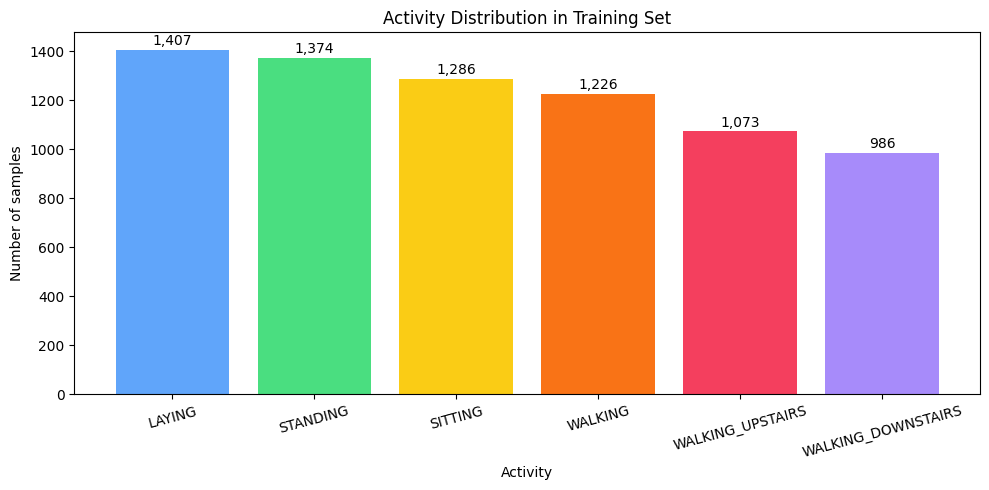

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

counts = train['Activity'].value_counts()
colors = ['#60a5fa', '#4ade80', '#facc15', '#f97316', '#f43f5e', '#a78bfa']
bars   = ax.bar(counts.index, counts.values, color=colors)

ax.set_title('Activity Distribution in Training Set')
ax.set_xlabel('Activity')
ax.set_ylabel('Number of samples')
ax.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Cell 4 — Prepare features and labels

We separate the sensor features (X) from the activity label (y) in both train and test sets.

We also drop the `subject` column — this is the volunteer ID number. If we kept it, the model might learn to recognize specific people instead of activity patterns, which would not generalize to new users.

**LabelEncoder** converts the text activity names into numbers:
- LAYING → 0
- SITTING → 1
- STANDING → 2
- WALKING → 3
- WALKING_DOWNSTAIRS → 4
- WALKING_UPSTAIRS → 5

In [4]:
# Drop subject ID — not useful for generalization
drop_cols = ['subject'] if 'subject' in train.columns else []

X_train = train.drop(['Activity'] + drop_cols, axis=1)
X_test  = test.drop(['Activity'] + drop_cols, axis=1)

le = LabelEncoder()
y_train = le.fit_transform(train['Activity'])
y_test  = le.transform(test['Activity'])

feature_cols = X_train.columns.tolist()
classes      = le.classes_.tolist()

print(f'Features: {len(feature_cols)}')
print(f'Classes:  {classes}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

Features: 561
Classes:  ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
X_train shape: (7352, 561)
X_test shape:  (2947, 561)


## Cell 5 — Train Random Forest

**Why Random Forest for activity recognition?**

Random Forest builds many decision trees on random subsets of the data and features, then combines their predictions. This works well here because:

- 561 features is a lot — Random Forest handles high-dimensional data naturally
- The sensor patterns are non-linear — trees capture this without needing feature scaling
- It is fast at prediction time — important for real-time activity detection on a phone
- It gives feature importance — we can see which sensors matter most

**Key parameters:**
- `n_estimators=200` — build 200 trees
- `max_depth=20` — limit tree depth to prevent overfitting
- `n_jobs=-1` — use all CPU cores

In [5]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest...')
model.fit(X_train, y_train)
print('Training complete.')

Training Random Forest...
Training complete.


## Cell 6 — Evaluate the model

Activity recognition is a multi-class problem — we are predicting one of 6 activities, not just yes/no. So we use **accuracy** as the primary metric here, unlike the fraud and churn models where accuracy was misleading due to class imbalance.

For this dataset, a well-tuned model should achieve 92-96% accuracy. The hardest classes to separate are usually SITTING vs STANDING since the sensor signals are similar for both.

In [6]:
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=classes))

Accuracy: 0.9298 (93.0%)

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.92      0.88      0.90       491
          STANDING       0.90      0.93      0.91       532
           WALKING       0.90      0.98      0.94       496
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
  WALKING_UPSTAIRS       0.90      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



## Cell 7 — Confusion matrix

The confusion matrix for a 6-class problem shows us exactly where the model gets confused. Each row is the actual activity, each column is the predicted activity.

The diagonal should be bright — those are correct predictions. Off-diagonal cells show misclassifications. We expect to see some confusion between SITTING and STANDING since they look similar to sensors.

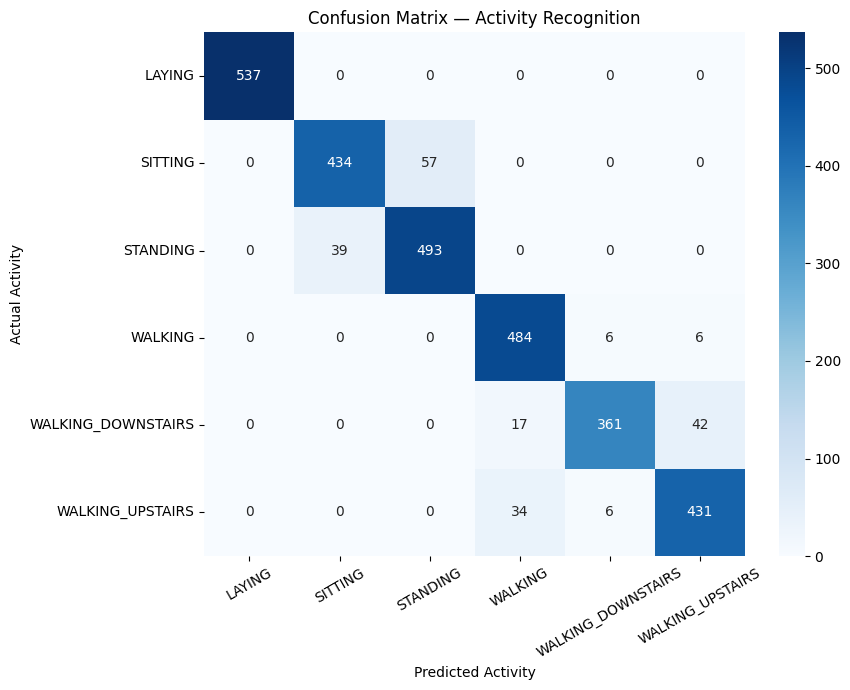

In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax
)
ax.set_title('Confusion Matrix — Activity Recognition')
ax.set_xlabel('Predicted Activity')
ax.set_ylabel('Actual Activity')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Cell 8 — Feature importance

Which of the 561 sensor features does the model rely on most?

Typically the most important features are:
- Body acceleration mean and standard deviation
- Gravity acceleration components
- Jerk signals — the rate of change of acceleration, which distinguishes walking from standing

This chart shows the top 20 most important features out of 561.

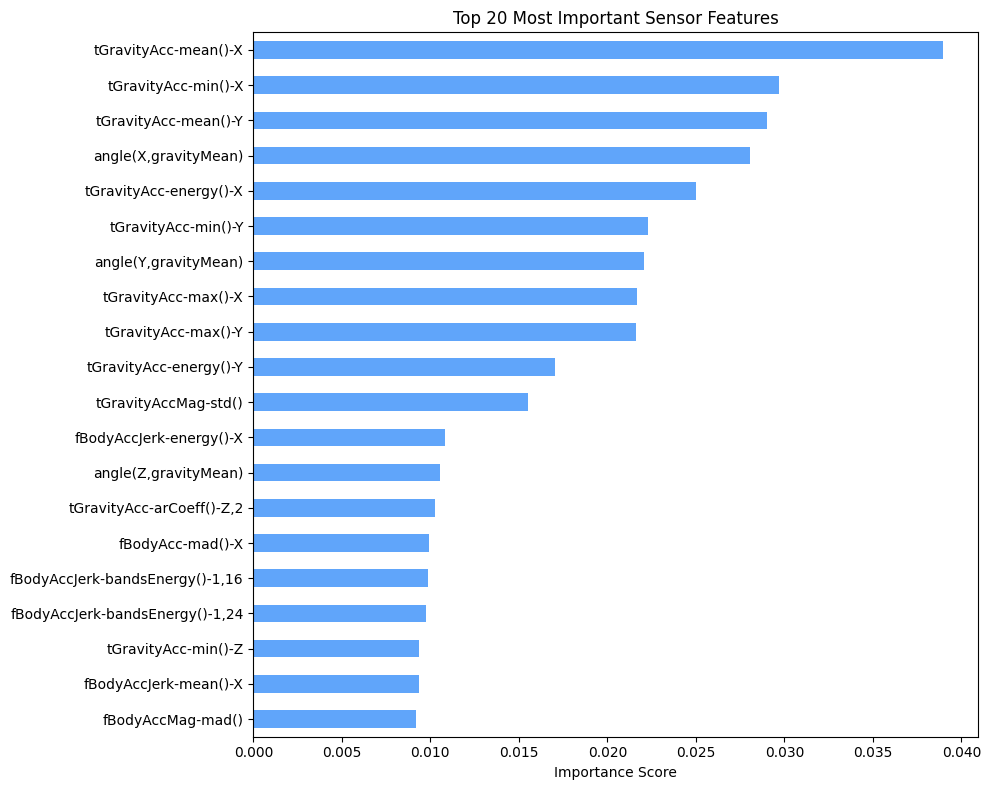

In [8]:
importance = pd.Series(model.feature_importances_, index=feature_cols)
top20      = importance.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#60a5fa')
ax.set_title('Top 20 Most Important Sensor Features')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Cell 9 — The Danger Scoring Engine

**This is the core of Project 07.**

The activity classifier tells us WHAT the person is doing. The danger scoring engine takes that activity plus context and decides HOW DANGEROUS the situation might be.

**Danger rules:**

| Scenario | Danger Score | Reasoning |
|----------|-------------|----------|
| LAYING at 2am for 30+ min | 85 | Possible incapacitation |
| WALKING → sudden LAYING | 90 | Possible fall or attack |
| STANDING still for 20+ min at night | 70 | Possible distress |
| SITTING at unusual hour + no interaction | 60 | Welfare check needed |
| WALKING normally in daytime | 10 | Normal |

The score is 0-100. Above 70 = alert sent to trusted contact.

In [9]:
def calculate_danger_score(
    activity: str,
    hour: int,
    duration_minutes: int,
    previous_activity: str = None,
    activity_confidence: float = 1.0
) -> dict:
    """
    Calculate a danger score from 0-100 based on:
    - Current activity
    - Time of day
    - How long the activity has been ongoing
    - What the previous activity was (to detect sudden transitions)
    - Model confidence in the activity prediction
    """
    score   = 0
    reasons = []

    is_night = hour >= 22 or hour <= 5
    is_late  = hour >= 20 or hour <= 7

    # Sudden transition from walking to laying = possible fall
    if previous_activity in ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'] \
       and activity == 'LAYING':
        score += 50
        reasons.append('Sudden transition from walking to laying — possible fall')

    # Laying rules
    if activity == 'LAYING':
        if is_night and duration_minutes > 30:
            score += 30
            reasons.append(f'Laying for {duration_minutes} min at night — possible incapacitation')
        elif not is_night and duration_minutes > 20:
            score += 40
            reasons.append(f'Laying for {duration_minutes} min during day — unusual')

    # Standing still for a long time
    if activity == 'STANDING':
        if duration_minutes > 20 and is_night:
            score += 35
            reasons.append(f'Standing still for {duration_minutes} min at night')
        elif duration_minutes > 30:
            score += 20
            reasons.append(f'Standing still for {duration_minutes} min')

    # Sitting rules
    if activity == 'SITTING':
        if is_night and duration_minutes > 45:
            score += 25
            reasons.append(f'Sitting for {duration_minutes} min at night')

    # Night time multiplier — everything is more concerning at night
    if is_night and score > 0:
        score = int(score * 1.3)
        reasons.append('Night time increases risk level')

    # Low confidence multiplier
    if activity_confidence < 0.6:
        score = int(score * 1.1)
        reasons.append('Low confidence in activity detection')

    score = min(score, 100)

    if score >= 70:
        alert_level = 'CRITICAL'
        action      = 'Send alert to trusted contact immediately'
    elif score >= 45:
        alert_level = 'WARNING'
        action      = 'Send check-in notification to user'
    elif score >= 20:
        alert_level = 'CAUTION'
        action      = 'Monitor closely'
    else:
        alert_level = 'SAFE'
        action      = 'No action needed'

    if not reasons:
        reasons.append('Normal activity pattern detected')

    return {
        'danger_score': score,
        'alert_level':  alert_level,
        'action':       action,
        'reasons':      reasons,
        'activity':     activity,
        'hour':         hour,
        'duration_min': duration_minutes,
    }

print('Danger scoring engine defined.')

Danger scoring engine defined.


## Cell 10 — Test the danger scoring engine

Let's run four realistic scenarios through the engine to confirm it works correctly.

Each scenario represents a real-world situation a user might be in.

In [10]:
scenarios = [
    {
        'name': 'Walking home normally at 6pm',
        'activity': 'WALKING',
        'hour': 18,
        'duration_minutes': 15,
        'previous_activity': None,
    },
    {
        'name': 'Suddenly laying after walking at 11pm',
        'activity': 'LAYING',
        'hour': 23,
        'duration_minutes': 5,
        'previous_activity': 'WALKING',
    },
    {
        'name': 'Standing still for 25 minutes at 1am',
        'activity': 'STANDING',
        'hour': 1,
        'duration_minutes': 25,
        'previous_activity': None,
    },
    {
        'name': 'Laying during day for 25 minutes',
        'activity': 'LAYING',
        'hour': 14,
        'duration_minutes': 25,
        'previous_activity': 'SITTING',
    },
]

for s in scenarios:
    result = calculate_danger_score(
        activity=s['activity'],
        hour=s['hour'],
        duration_minutes=s['duration_minutes'],
        previous_activity=s['previous_activity'],
    )
    print(f"Scenario: {s['name']}")
    print(f"  Danger score: {result['danger_score']}/100")
    print(f"  Alert level:  {result['alert_level']}")
    print(f"  Action:       {result['action']}")
    print(f"  Reasons:      {result['reasons']}")
    print()

Scenario: Walking home normally at 6pm
  Danger score: 0/100
  Alert level:  SAFE
  Action:       No action needed
  Reasons:      ['Normal activity pattern detected']

Scenario: Suddenly laying after walking at 11pm
  Danger score: 65/100
  Alert level:  WARNING
  Action:       Send check-in notification to user
  Reasons:      ['Sudden transition from walking to laying — possible fall', 'Night time increases risk level']

Scenario: Standing still for 25 minutes at 1am
  Danger score: 45/100
  Alert level:  WARNING
  Action:       Send check-in notification to user
  Reasons:      ['Standing still for 25 min at night', 'Night time increases risk level']

Scenario: Laying during day for 25 minutes
  Danger score: 40/100
  Alert level:  CAUTION
  Action:       Monitor closely
  Reasons:      ['Laying for 25 min during day — unusual']



## Cell 11 — Full pipeline test

Now we test the complete two-layer pipeline:
1. Feed raw sensor data into the activity classifier
2. Take the predicted activity and feed it into the danger scoring engine

This is exactly what the API will do when it receives a real request.

In [11]:
# Take a real LAYING sample from test set
laying_idx    = test[test['Activity'] == 'LAYING'].index[0]
sample_X      = X_test.loc[[laying_idx]]
sample_true   = test.loc[laying_idx, 'Activity']

# Step 1 — Predict activity
pred_encoded  = model.predict(sample_X)[0]
pred_proba    = model.predict_proba(sample_X)[0]
pred_activity = le.inverse_transform([pred_encoded])[0]
confidence    = float(pred_proba.max())

print(f'True activity:      {sample_true}')
print(f'Predicted activity: {pred_activity}')
print(f'Confidence:         {confidence:.1%}')
print()

# Step 2 — Score the danger (simulating 2am, laying for 35 minutes)
result = calculate_danger_score(
    activity=pred_activity,
    hour=2,
    duration_minutes=35,
    previous_activity='WALKING',
    activity_confidence=confidence
)

print('Danger assessment:')
for k, v in result.items():
    print(f'  {k}: {v}')

True activity:      LAYING
Predicted activity: LAYING
Confidence:         100.0%

Danger assessment:
  danger_score: 100
  alert_level: CRITICAL
  action: Send alert to trusted contact immediately
  reasons: ['Sudden transition from walking to laying — possible fall', 'Laying for 35 min at night — possible incapacitation', 'Night time increases risk level']
  activity: LAYING
  hour: 2
  duration_min: 35


## Cell 12 — Save the model

We save the activity classifier, label encoder, feature columns, and model accuracy so the API can load everything it needs.

In [12]:
model_artifacts = {
    'model':        model,
    'label_encoder': le,
    'feature_cols': feature_cols,
    'classes':      classes,
    'accuracy':     round(acc, 4),
}

with open('../safety_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print('Model saved to safety_model.pkl')
print(f'  Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print(f'  Classes:  {classes}')

Model saved to safety_model.pkl
  Accuracy: 0.9298 (93.0%)
  Classes:  ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


## Cell 13 — Sanity check

Load the saved model and confirm the full pipeline works end to end.

In [13]:
with open('../safety_model.pkl', 'rb') as f:
    saved = pickle.load(f)

# Test one sample from each activity
print('Sanity check — one sample per activity:')
print()

for activity in classes:
    idx      = test[test['Activity'] == activity].index[0]
    sample   = X_test.loc[[idx]]
    pred_enc = saved['model'].predict(sample)[0]
    pred_act = saved['label_encoder'].inverse_transform([pred_enc])[0]
    correct  = '✓' if pred_act == activity else '✗'
    print(f'  {correct} True: {activity:<25} Predicted: {pred_act}')

print()
print(f'Model accuracy on full test set: {saved["accuracy"] * 100:.1f}%')

Sanity check — one sample per activity:

  ✓ True: LAYING                    Predicted: LAYING
  ✗ True: SITTING                   Predicted: STANDING
  ✓ True: STANDING                  Predicted: STANDING
  ✓ True: WALKING                   Predicted: WALKING
  ✓ True: WALKING_DOWNSTAIRS        Predicted: WALKING_DOWNSTAIRS
  ✓ True: WALKING_UPSTAIRS          Predicted: WALKING_UPSTAIRS

Model accuracy on full test set: 93.0%


---
## Done

`safety_model.pkl` is saved and ready for the FastAPI server.

**What this system can do:**
- Classify phone sensor data into 6 activity types with high accuracy
- Score the danger level of any activity based on context
- Explain exactly why a situation was flagged as dangerous
- Trigger appropriate alerts based on the danger level

**Next step:** Build `api.py` — the FastAPI server that accepts sensor readings and context, classifies the activity, scores the danger, and returns an alert decision.